# Unified SARIMA vs Supervised Benchmark

This notebook evaluates SARIMA and supervised models under one shared protocol:
- Same candidate merchants and coverage rules
- Same weighted k-NN neighbor transfer and composite merchant construction
- Same Jan calibration window and Feb-Apr evaluation window
- Both `raw` and `guarded calibration` variants for every model

In [8]:
# Core
import numpy as np
import pandas as pd

# Visualization (optional but useful for diagnostics)
import matplotlib.pyplot as plt
import seaborn as sns

# Data prep and evaluation
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Supervised regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNetCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Time-series model
from statsmodels.tsa.statespace.sarimax import SARIMAX

# XGBoost
from xgboost import XGBRegressor

In [4]:
# Shared configuration
COST_TYPE_IDS = list(range(1, 62))
ID_COLS = ['split_year', 'week_of_year', 'merchant_id']

MIN_JAN_NON_NULL = 2
MIN_FEB_APR_NON_NULL = 8
JAN_WEEKS = [1, 2, 3, 4]
FORECAST_WEEKS = list(range(1, 17))
EVAL_WEEKS = list(range(5, 17))
K_NEIGHBORS = 5
EPS = 1e-9

N_LAGS = 8

CALIBRATION_MIN_PRED_STD = 1e-4
CALIBRATION_MAX_ABS_SLOPE = 10.0

FAST_MODE = False
FAST_MODE_MAX_MERCHANTS = 80


def build_weekly_merchant_features(df, split_year):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df = df[df['date'].dt.year == split_year].copy()

    year_start = pd.Timestamp(f'{split_year}-01-01')
    day_offset = (df['date'] - year_start).dt.days
    df['week_of_year'] = np.clip((day_offset // 7) + 1, 1, 52).astype(int)

    df['cost_type_ID'] = pd.to_numeric(df['cost_type_ID'], errors='coerce').astype('Int64')
    df['txn_cost_percent'] = np.where(df['amount'] != 0, df['proc_cost'] / df['amount'], np.nan)

    weekly_summary = (
        df.groupby(['merchant_id', 'week_of_year'], as_index=False)
        .agg(
            total_proc_cost=('proc_cost', 'sum'),
            total_amount=('amount', 'sum'),
            total_transactions=('transaction_id', 'count'),
            cost_percent_stdev=('txn_cost_percent', 'std'),
        )
    )

    weekly_summary['cost_percent'] = np.where(
        weekly_summary['total_amount'] != 0,
        weekly_summary['total_proc_cost'] / weekly_summary['total_amount'],
        np.nan,
    )
    weekly_summary = weekly_summary.drop(columns=['total_proc_cost', 'total_amount'])

    cost_type_counts = (
        df.dropna(subset=['cost_type_ID'])
        .groupby(['merchant_id', 'week_of_year', 'cost_type_ID'])['transaction_id']
        .count()
        .unstack(fill_value=0)
        .reindex(columns=COST_TYPE_IDS, fill_value=0)
    )

    cost_type_pct = cost_type_counts.div(cost_type_counts.sum(axis=1), axis=0).fillna(0)
    cost_type_pct.columns = [f'pct_cost_type_{cost_type_id}' for cost_type_id in cost_type_pct.columns]
    cost_type_pct = cost_type_pct.reset_index()

    weekly_features = weekly_summary.merge(
        cost_type_pct,
        on=['merchant_id', 'week_of_year'],
        how='left',
    )

    merchants = pd.Index(sorted(df['merchant_id'].dropna().unique()), name='merchant_id')
    weeks = pd.Index(range(1, 53), name='week_of_year')
    full_grid = pd.MultiIndex.from_product([merchants, weeks], names=['merchant_id', 'week_of_year']).to_frame(index=False)

    weekly_features = full_grid.merge(
        weekly_features,
        on=['merchant_id', 'week_of_year'],
        how='left',
    )

    pct_cols = [f'pct_cost_type_{cost_type_id}' for cost_type_id in COST_TYPE_IDS]
    weekly_features[pct_cols] = weekly_features[pct_cols].fillna(0.0)
    weekly_features['total_transactions'] = weekly_features['total_transactions'].fillna(0).astype(int)
    weekly_features['split_year'] = split_year

    ordered_cols = [
        'split_year',
        'week_of_year',
        'merchant_id',
        'cost_percent',
        *pct_cols,
        'total_transactions',
        'cost_percent_stdev',
    ]

    weekly_features = weekly_features[ordered_cols].sort_values(['merchant_id', 'week_of_year']).reset_index(drop=True)
    return weekly_features


def build_weekly_trajectory_matrix(df, trajectory_feature_cols, target_weeks, merchant_col='merchant_id'):
    tmp = df[df['week_of_year'].isin(target_weeks)].copy()
    tmp = tmp[[merchant_col, 'week_of_year'] + trajectory_feature_cols]

    tmp = (
        tmp.groupby([merchant_col, 'week_of_year'], as_index=False)[trajectory_feature_cols]
        .mean()
    )

    merchants = sorted(tmp[merchant_col].unique())
    blocks = []
    for wk in target_weeks:
        wk_df = (
            tmp[tmp['week_of_year'] == wk]
            .set_index(merchant_col)[trajectory_feature_cols]
            .reindex(merchants)
            .fillna(0.0)
        )
        wk_df.columns = [f'w{wk}_{c}' for c in trajectory_feature_cols]
        blocks.append(wk_df)

    traj_df = pd.concat(blocks, axis=1)
    traj_df.index.name = merchant_col
    return traj_df.reset_index()


def make_lag_matrix(series, n_lags):
    X_vals, y_vals = [], []
    for t in range(n_lags, len(series)):
        X_vals.append(series[t - n_lags:t])
        y_vals.append(series[t])
    return np.asarray(X_vals, dtype=float), np.asarray(y_vals, dtype=float)


def recursive_forecast(model, history, n_lags, horizon):
    history_vals = list(np.asarray(history, dtype=float).copy())
    preds = []
    for _ in range(horizon):
        x_next = np.asarray(history_vals[-n_lags:], dtype=float).reshape(1, -1)
        y_next = float(model.predict(x_next)[0])
        preds.append(y_next)
        history_vals.append(y_next)
    return np.asarray(preds, dtype=float)


def fit_guarded_calibrator(jan_df, pred_col='raw_pred', target_col='actual_cost_percent'):
    if len(jan_df) < MIN_JAN_NON_NULL:
        raise ValueError('insufficient_jan_points_for_calibration')

    pred_vals = jan_df[pred_col].to_numpy(dtype=float)
    actual_vals = jan_df[target_col].to_numpy(dtype=float)
    pred_std = float(np.std(pred_vals, ddof=0))
    actual_mean = float(np.mean(actual_vals))

    if pred_std < CALIBRATION_MIN_PRED_STD:
        return {
            'mode': 'intercept_only_low_pred_std',
            'intercept': actual_mean,
            'slope': 0.0,
            'pred_std': pred_std,
        }

    linear_calibrator = LinearRegression()
    linear_calibrator.fit(jan_df[[pred_col]], jan_df[target_col])
    intercept = float(linear_calibrator.intercept_)
    slope = float(linear_calibrator.coef_[0])

    if (not np.isfinite(slope)) or abs(slope) > CALIBRATION_MAX_ABS_SLOPE:
        return {
            'mode': 'intercept_only_slope_guard',
            'intercept': actual_mean,
            'slope': 0.0,
            'pred_std': pred_std,
            'raw_intercept': intercept,
            'raw_slope': slope,
        }

    return {
        'mode': 'linear',
        'intercept': intercept,
        'slope': slope,
        'pred_std': pred_std,
    }


def apply_calibrator(raw_pred_series, calibrator_info):
    return calibrator_info['intercept'] + calibrator_info['slope'] * raw_pred_series

In [5]:
# Load and prepare data
train_df = pd.read_csv('5411_train_temporal_with_costs.csv')
val_df = pd.read_csv('5411_validate_temporal_with_costs.csv')
test_df = pd.read_csv('5411_test_temporal_with_costs.csv')

all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

all_df = all_df[all_df['cost_type_ID'] != 'NaN']
train_df = train_df[train_df['cost_type_ID'] != 'NaN']
val_df = val_df[val_df['cost_type_ID'] != 'NaN']
test_df = test_df[test_df['cost_type_ID'] != 'NaN']

train_df = train_df.dropna(subset=['cost_type_ID'])
val_df = val_df.dropna(subset=['cost_type_ID'])
test_df = test_df.dropna(subset=['cost_type_ID'])
all_df = all_df.dropna(subset=['cost_type_ID'])

train_df = train_df[train_df['errors'].isna()].copy()
val_df = val_df[val_df['errors'].isna()].copy()
test_df = test_df[test_df['errors'].isna()].copy()
all_df = all_df[all_df['errors'].isna()].copy()

weekly_train_features = build_weekly_merchant_features(train_df, 2017)
weekly_validate_features = build_weekly_merchant_features(val_df, 2018)
weekly_test_features = build_weekly_merchant_features(test_df, 2019)

all_weekly_df = pd.concat(
    [weekly_train_features, weekly_validate_features, weekly_test_features],
    ignore_index=True,
).sort_values(['split_year', 'merchant_id', 'week_of_year']).reset_index(drop=True)

feature_cols = [col for col in all_weekly_df.columns if col not in ID_COLS]

print('Prepared weekly panel')
print('All weekly rows:', len(all_weekly_df))
print('Feature count:', len(feature_cols))
print('Merchants in 2019:', weekly_test_features['merchant_id'].nunique())

Prepared weekly panel
All weekly rows: 420108
Feature count: 64
Merchants in 2019: 2552


In [9]:
# Unified CV: SARIMA + Supervised, each with raw and guarded variants

model_specs = {
    'linear': lambda: LinearRegression(),
    'ridge': lambda: Ridge(alpha=0.5),
    'lasso': lambda: Lasso(alpha=0.001, max_iter=5000),
    'enetcv': lambda: ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-6, -2, 25),
        cv=5,
        max_iter=10000,
        fit_intercept=True,
    ),
    'dt': lambda: DecisionTreeRegressor(max_depth=5, min_samples_leaf=2, random_state=42),
    'xgb': lambda: XGBRegressor(max_depth=3, learning_rate=0.05, n_estimators=100, random_state=42, verbosity=0),
    'rf': lambda: RandomForestRegressor(n_estimators=100, max_depth=8, min_samples_leaf=2, random_state=42, n_jobs=1),
}

# Candidate merchants: reproducible random sample of 700 from all merchants present in 2019 weekly features.
all_merchants_2019 = sorted(weekly_test_features['merchant_id'].dropna().unique().tolist())
sample_size = min(700, len(all_merchants_2019))
rng = np.random.default_rng(42)
candidate_merchants = sorted(rng.choice(all_merchants_2019, size=sample_size, replace=False).tolist())

if FAST_MODE:
    candidate_merchants = candidate_merchants[:FAST_MODE_MAX_MERCHANTS]

print('Unified benchmark setup')
print('Total merchants in 2019:', len(all_merchants_2019))
print('Candidate merchants (random sample):', len(candidate_merchants))
print('Coverage filtering: DISABLED')

cv_rows = []
cv_failures = []

for i, merchant_id in enumerate(candidate_merchants, start=1):
    try:
        pool_history = all_weekly_df[(all_weekly_df['split_year'].isin([2017, 2018])) & (all_weekly_df['merchant_id'] != merchant_id)].copy()
        if pool_history.empty:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'empty_pool'})
            continue

        cv_scaler = StandardScaler()
        cv_scaler.fit(pool_history[feature_cols].fillna(0.0))

        pool_history_z = pool_history[ID_COLS].copy()
        pool_history_z[feature_cols] = cv_scaler.transform(pool_history[feature_cols].fillna(0.0))

        query_jan = weekly_test_features[(weekly_test_features['merchant_id'] == merchant_id) & (weekly_test_features['week_of_year'].isin(JAN_WEEKS))][ID_COLS + feature_cols].copy()
        if query_jan.empty:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'empty_query_jan'})
            continue

        query_jan_z = query_jan[ID_COLS].copy()
        query_jan_z[feature_cols] = cv_scaler.transform(query_jan[feature_cols].fillna(0.0))

        pool_traj = build_weekly_trajectory_matrix(pool_history_z, feature_cols, JAN_WEEKS)
        query_traj = build_weekly_trajectory_matrix(query_jan_z, feature_cols, JAN_WEEKS)
        if pool_traj.empty or query_traj.empty:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'empty_trajectory'})
            continue

        X_pool = pool_traj.drop(columns=['merchant_id']).values
        X_query = query_traj.drop(columns=['merchant_id']).values
        pool_ids = pool_traj['merchant_id'].values

        traj_feature_names = pool_traj.drop(columns=['merchant_id']).columns.tolist()
        feature_weight_map = {name: 1.0 for name in traj_feature_names}
        for fname in traj_feature_names:
            if fname.endswith('_cost_percent'):
                feature_weight_map[fname] = 3.0
            elif fname.endswith('_total_transactions'):
                feature_weight_map[fname] = 2.5
            elif fname.endswith('_cost_percent_stdev'):
                feature_weight_map[fname] = 2.0

        weight_vector = np.array([feature_weight_map[name] for name in traj_feature_names])
        weighted_dist = np.sqrt((((X_pool - X_query[0]) ** 2) * weight_vector).sum(axis=1))

        k_local = min(K_NEIGHBORS, len(weighted_dist))
        top_idx = np.argsort(weighted_dist)[:k_local]
        nn_df = pd.DataFrame({
            'neighbor_merchant_id': pool_ids[top_idx].astype(int),
            'distance': weighted_dist[top_idx].astype(float),
        })
        nn_df['raw_weight'] = 1.0 / (nn_df['distance'] + EPS)
        nn_df['neighbor_weight'] = nn_df['raw_weight'] / nn_df['raw_weight'].sum()

        neighbor_history = all_weekly_df[
            (all_weekly_df['split_year'].isin([2017, 2018]))
            & (all_weekly_df['merchant_id'].isin(nn_df['neighbor_merchant_id']))
            & (all_weekly_df['merchant_id'] != merchant_id)
        ].copy()
        if neighbor_history.empty:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'empty_neighbor_history'})
            continue

        neighbor_weights = nn_df.rename(columns={'neighbor_merchant_id': 'merchant_id'})[['merchant_id', 'neighbor_weight']]
        neighbor_history = neighbor_history.merge(neighbor_weights, on='merchant_id', how='left')

        composite_cv = (
            neighbor_history
            .assign(**{col: neighbor_history[col] * neighbor_history['neighbor_weight'] for col in feature_cols})
            .groupby(['split_year', 'week_of_year'], as_index=False)[feature_cols]
            .sum()
            .sort_values(['split_year', 'week_of_year'])
            .reset_index(drop=True)
        )

        y_train_cv = composite_cv['cost_percent'].astype(float).interpolate(limit_direction='both').ffill().bfill().to_numpy()
        if len(y_train_cv) < N_LAGS + 4:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'insufficient_composite_length'})
            continue

        truth_1_16 = (
            weekly_test_features[(weekly_test_features['merchant_id'] == merchant_id) & (weekly_test_features['week_of_year'].between(1, 16))][['week_of_year', 'cost_percent']]
            .set_index('week_of_year')
            .reindex(FORECAST_WEEKS)
            .rename_axis('week_of_year')
            .reset_index()
        )

        jan_actual_non_null = (
            truth_1_16[truth_1_16['week_of_year'].isin(JAN_WEEKS)]['cost_percent']
            .astype(float)
            .dropna()
        )
        if len(jan_actual_non_null) < MIN_JAN_NON_NULL:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'insufficient_jan_actual_for_janmean_baseline'})
            continue
        jan_mean_value = float(jan_actual_non_null.mean())

        model_predictions = {}

        # SARIMA predictions
        try:
            sarima_model = SARIMAX(
                y_train_cv,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 52),
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            sarima_result = sarima_model.fit(disp=False)
            sarima_used = 'SARIMA(1,1,1)x(1,1,1,52)'
        except Exception:
            sarima_model = SARIMAX(
                y_train_cv,
                order=(1, 1, 1),
                seasonal_order=(0, 0, 0, 0),
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            sarima_result = sarima_model.fit(disp=False)
            sarima_used = 'ARIMA(1,1,1) fallback'

        sarima_forecast = sarima_result.get_forecast(steps=len(FORECAST_WEEKS))
        sarima_preds = np.asarray(sarima_forecast.predicted_mean, dtype=float)
        model_predictions['sarima'] = {'pred': sarima_preds, 'model_used': sarima_used}

        # Supervised predictions
        X_cv_train, y_cv_train = make_lag_matrix(y_train_cv, N_LAGS)
        if len(X_cv_train) < 10:
            cv_failures.append({'merchant_id': merchant_id, 'reason': 'insufficient_train_rows'})
            continue

        for model_key, model_factory in model_specs.items():
            model = model_factory()
            model.fit(X_cv_train, y_cv_train)
            preds = recursive_forecast(model, y_train_cv, N_LAGS, len(FORECAST_WEEKS))
            model_predictions[model_key] = {'pred': preds, 'model_used': model_key}

        # Baseline: constant Jan mean from query merchant, no calibration.
        model_predictions['jan_mean_baseline'] = {
            'pred': np.full(len(FORECAST_WEEKS), jan_mean_value, dtype=float),
            'model_used': 'jan_mean_baseline',
            'skip_guarded_calibration': True,
        }

        # Unified scoring (raw + guarded)
        for model_key, payload in model_predictions.items():
            eval_df = pd.DataFrame({
                'week_of_year': FORECAST_WEEKS,
                'actual_cost_percent': truth_1_16['cost_percent'].astype(float).values,
                'raw_pred': payload['pred'],
            })

            jan_fit = eval_df[eval_df['week_of_year'].between(1, 4)].dropna(subset=['actual_cost_percent']).copy()
            feb_apr_eval = eval_df[eval_df['week_of_year'].isin(EVAL_WEEKS)].dropna(subset=['actual_cost_percent']).copy()

            if len(jan_fit) < MIN_JAN_NON_NULL or len(feb_apr_eval) < MIN_FEB_APR_NON_NULL:
                continue

            raw_mae = mean_absolute_error(feb_apr_eval['actual_cost_percent'], feb_apr_eval['raw_pred'])
            raw_rmse = np.sqrt(mean_squared_error(feb_apr_eval['actual_cost_percent'], feb_apr_eval['raw_pred']))

            if payload.get('skip_guarded_calibration', False):
                eval_df['guarded_pred'] = eval_df['raw_pred']
                calibrator_info = {
                    'mode': 'none_jan_mean_baseline',
                    'intercept': jan_mean_value,
                    'slope': 1.0,
                }
            else:
                calibrator_info = fit_guarded_calibrator(jan_fit, pred_col='raw_pred', target_col='actual_cost_percent')
                eval_df['guarded_pred'] = apply_calibrator(eval_df['raw_pred'], calibrator_info)

            feb_apr_guarded = eval_df[eval_df['week_of_year'].isin(EVAL_WEEKS)].dropna(subset=['actual_cost_percent']).copy()
            guarded_mae = mean_absolute_error(feb_apr_guarded['actual_cost_percent'], feb_apr_guarded['guarded_pred'])
            guarded_rmse = np.sqrt(mean_squared_error(feb_apr_guarded['actual_cost_percent'], feb_apr_guarded['guarded_pred']))

            cv_rows.append({
                'merchant_id': int(merchant_id),
                'model': model_key,
                'model_used': payload['model_used'],
                'n_neighbors': int(k_local),
                'n_feb_apr_points': int(len(feb_apr_eval)),
                'raw_mae': float(raw_mae),
                'raw_rmse': float(raw_rmse),
                'guarded_mae': float(guarded_mae),
                'guarded_rmse': float(guarded_rmse),
                'mae_improvement_pct': float((raw_mae - guarded_mae) / np.clip(raw_mae, 1e-12, None) * 100),
                'rmse_improvement_pct': float((raw_rmse - guarded_rmse) / np.clip(raw_rmse, 1e-12, None) * 100),
                'calibration_mode': calibrator_info['mode'],
                'calibration_intercept': float(calibrator_info['intercept']),
                'calibration_slope': float(calibrator_info['slope']),
            })

    except Exception as exc:
        cv_failures.append({'merchant_id': merchant_id, 'reason': f'exception: {type(exc).__name__}: {exc}'})

    if i % 25 == 0:
        print(f'Processed {i}/{len(candidate_merchants)} merchants...')

combined_results_df = pd.DataFrame(cv_rows)
combined_failures_df = pd.DataFrame(cv_failures)

print('')
print('Combined CV complete')
print('Candidate merchants:', len(candidate_merchants))
print('Result rows (merchant-model evaluations):', len(combined_results_df))
print('Failure rows:', len(combined_failures_df))

if not combined_results_df.empty:
    print('Models present:', sorted(combined_results_df['model'].unique().tolist()))

Unified benchmark setup
Total merchants in 2019: 2552
Candidate merchants (random sample): 700
Coverage filtering: DISABLED


/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/

Processed 25/700 merchants...


/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/

Processed 200/700 merchants...


...

Processed 275/700 merchants...


/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/

Processed 525/700 merchants...


/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/Users/


Combined CV complete
Candidate merchants: 700
Result rows (merchant-model evaluations): 1314
Failure rows: 485
Models present: ['dt', 'enetcv', 'jan_mean_baseline', 'lasso', 'linear', 'rf', 'ridge', 'sarima', 'xgb']


Strict aligned merchant set size: 146
Total models compared: 9


,model_name,merchants,mean_raw_mae,mean_guarded_mae,median_raw_mae,median_guarded_mae,mean_raw_rmse,mean_guarded_rmse,mae_guarded_win_rate_pct,rmse_guarded_win_rate_pct
0,JanMeanBaseline_NoCal,146,0.017899,0.017899,0.008226,0.008226,0.022213,0.022213,0.000000,0.000000
1,LASSO,146,0.021381,0.017899,0.014034,0.008226,0.026978,0.022213,73.972603,74.657534
2,Ridge,146,0.021390,0.017910,0.014015,0.008226,0.026990,0.022226,73.287671,74.657534
3,ElasticNetCV,146,0.021424,0.018013,0.014492,0.008169,0.027032,0.022317,74.657534,76.027397
4,Linear,146,0.021812,0.018627,0.014826,0.008789,0.027478,0.022856,69.178082,69.863014
5,XGBoost,146,0.022031,0.019518,0.015422,0.009235,0.027740,0.024246,67.808219,70.547945
6,RandomForest,146,0.021949,0.019761,0.015032,0.009732,0.027673,0.024433,68.493151,69.863014
7,DecisionTree,146,0.022787,0.021187,0.015713,0.010123,0.029017,0.026592,72.602740,71.917808
8,SARIMA,146,0.025189,0.023233,0.018803,0.012977,0.031431,0.029227,71.232877,73.287671


,model_name,variant,mean_mae,median_mae,mean_rmse,median_rmse
4,JanMeanBaseline_NoCal,guarded,0.017899,0.008226,0.022213,0.011225
6,LASSO,guarded,0.017899,0.008226,0.022213,0.011225
12,Ridge,guarded,0.017910,0.008226,0.022226,0.011225
2,ElasticNetCV,guarded,0.018013,0.008169,0.022317,0.011460
8,Linear,guarded,0.018627,0.008789,0.022856,0.012400
16,XGBoost,guarded,0.019518,0.009235,0.024246,0.012611
10,RandomForest,guarded,0.019761,0.009732,0.024433,0.012379
0,DecisionTree,guarded,0.021187,0.010123,0.026592,0.013339
14,SARIMA,guarded,0.023233,0.012977,0.029227,0.017081
5,JanMeanBaseline_NoCal,raw,0.017899,0.008226,0.022213,0.011225


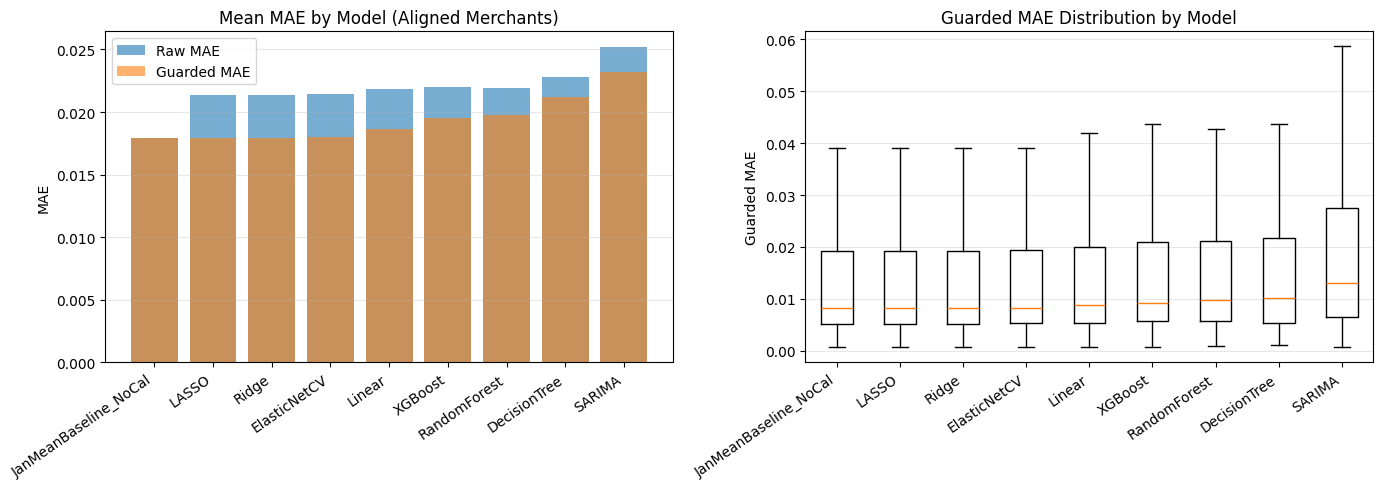

Calibration mode usage by model:


calibration_mode,intercept_only_low_pred_std,intercept_only_slope_guard,linear,none_jan_mean_baseline
model_name,,,,
DecisionTree,21,9,116,0
ElasticNetCV,97,21,28,0
JanMeanBaseline_NoCal,0,0,0,146
LASSO,146,0,0,0
Linear,10,19,117,0
RandomForest,6,21,119,0
Ridge,117,19,10,0
SARIMA,1,1,144,0
XGBoost,7,16,123,0


Interpretation guide:
  intercept_only_low_pred_std means Jan raw predictions were nearly flat, so calibration fell back to the Jan mean.
  intercept_only_slope_guard means the fitted Jan slope was too large, so calibration fell back to the Jan mean.
  linear means the normal Jan linear calibration passed the guard.
  none_jan_mean_baseline means the Jan-mean baseline is already uncalibrated, so raw=guarded by design.


In [10]:
# Summary tables and diagnostics under shared standards

if combined_results_df.empty:
    raise ValueError('No combined results. Run the CV cell first.')

name_map = {
    'sarima': 'SARIMA',
    'linear': 'Linear',
    'ridge': 'Ridge',
    'lasso': 'LASSO',
    'enetcv': 'ElasticNetCV',
    'dt': 'DecisionTree',
    'xgb': 'XGBoost',
    'rf': 'RandomForest',
    'jan_mean_baseline': 'JanMeanBaseline_NoCal',
}
combined_results_df['model_name'] = combined_results_df['model'].map(name_map).fillna(combined_results_df['model'])

# Restrict to merchants where every model has results (strict apples-to-apples set)
model_count = combined_results_df['model'].nunique()
merchant_model_counts = combined_results_df.groupby('merchant_id')['model'].nunique().reset_index(name='n_models')
complete_merchants = merchant_model_counts.loc[merchant_model_counts['n_models'] == model_count, 'merchant_id']
aligned_df = combined_results_df[combined_results_df['merchant_id'].isin(complete_merchants)].copy()

print('Strict aligned merchant set size:', len(complete_merchants))
print('Total models compared:', model_count)

summary_df = (
    aligned_df.groupby('model_name', as_index=False)
    .agg(
        merchants=('merchant_id', 'nunique'),
        mean_raw_mae=('raw_mae', 'mean'),
        mean_guarded_mae=('guarded_mae', 'mean'),
        median_raw_mae=('raw_mae', 'median'),
        median_guarded_mae=('guarded_mae', 'median'),
        mean_raw_rmse=('raw_rmse', 'mean'),
        mean_guarded_rmse=('guarded_rmse', 'mean'),
        mae_guarded_win_rate_pct=('mae_improvement_pct', lambda s: (s > 0).mean() * 100),
        rmse_guarded_win_rate_pct=('rmse_improvement_pct', lambda s: (s > 0).mean() * 100),
    )
    .sort_values('mean_guarded_mae')
    .reset_index(drop=True)
)

display(summary_df)

# Variant-level table (raw vs guarded)
raw_variant = aligned_df[['merchant_id', 'model_name', 'raw_mae', 'raw_rmse']].copy()
raw_variant['variant'] = 'raw'
raw_variant = raw_variant.rename(columns={'raw_mae': 'mae', 'raw_rmse': 'rmse'})

guarded_variant = aligned_df[['merchant_id', 'model_name', 'guarded_mae', 'guarded_rmse']].copy()
guarded_variant['variant'] = 'guarded'
guarded_variant = guarded_variant.rename(columns={'guarded_mae': 'mae', 'guarded_rmse': 'rmse'})

variant_df = pd.concat([raw_variant, guarded_variant], ignore_index=True)
variant_summary = (
    variant_df.groupby(['model_name', 'variant'], as_index=False)
    .agg(mean_mae=('mae', 'mean'), median_mae=('mae', 'median'), mean_rmse=('rmse', 'mean'), median_rmse=('rmse', 'median'))
    .sort_values(['variant', 'mean_mae'])
)

display(variant_summary)

# Plots
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.bar(summary_df['model_name'], summary_df['mean_raw_mae'], alpha=0.6, label='Raw MAE')
plt.bar(summary_df['model_name'], summary_df['mean_guarded_mae'], alpha=0.6, label='Guarded MAE')
plt.xticks(rotation=35, ha='right')
plt.ylabel('MAE')
plt.title('Mean MAE by Model (Aligned Merchants)')
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
box_models = summary_df['model_name'].tolist()
box_data = [aligned_df.loc[aligned_df['model_name'] == m, 'guarded_mae'].values for m in box_models]
plt.boxplot(box_data, tick_labels=box_models, showfliers=False)
plt.xticks(rotation=35, ha='right')
plt.ylabel('Guarded MAE')
plt.title('Guarded MAE Distribution by Model')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Calibration mode usage by model:')
cal_mode_table = pd.crosstab(aligned_df['model_name'], aligned_df['calibration_mode'])
display(cal_mode_table)

print('Interpretation guide:')
print('  intercept_only_low_pred_std means Jan raw predictions were nearly flat, so calibration fell back to the Jan mean.')
print('  intercept_only_slope_guard means the fitted Jan slope was too large, so calibration fell back to the Jan mean.')
print('  linear means the normal Jan linear calibration passed the guard.')
print('  none_jan_mean_baseline means the Jan-mean baseline is already uncalibrated, so raw=guarded by design.')

Sample merchants selected: [510, 51748, 99765]
Models plotted: ['sarima', 'jan_mean_baseline']


/Users/yattmeo/Desktop/SMU/Code/404_found_us/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


KeyError: 'jan_mean_baseline'

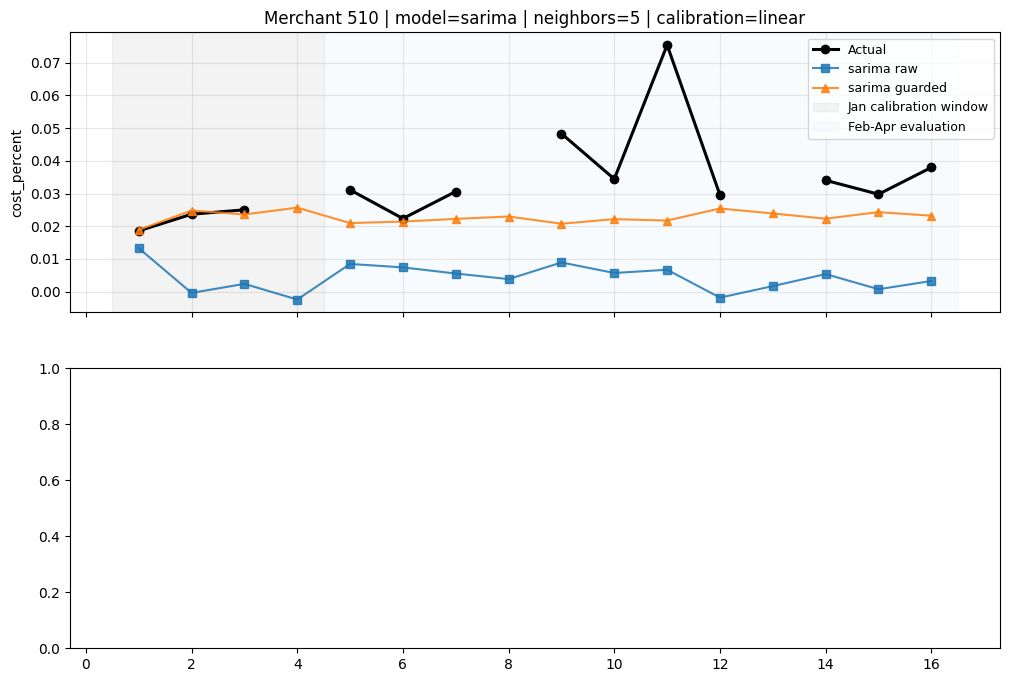

In [11]:
# Sample prediction visualisation: actual vs raw vs guarded
# Reconstructs predictions with the same transfer + model logic used in the unified CV cell.

if combined_results_df.empty:
    raise ValueError('Run the unified CV cell first so combined_results_df is available.')


def build_composite_for_merchant(merchant_id):
    pool_history = all_weekly_df[
        (all_weekly_df['split_year'].isin([2017, 2018]))
        & (all_weekly_df['merchant_id'] != merchant_id)
    ].copy()
    if pool_history.empty:
        raise ValueError('empty_pool')

    cv_scaler = StandardScaler()
    cv_scaler.fit(pool_history[feature_cols].fillna(0.0))

    pool_history_z = pool_history[ID_COLS].copy()
    pool_history_z[feature_cols] = cv_scaler.transform(pool_history[feature_cols].fillna(0.0))

    query_jan = weekly_test_features[
        (weekly_test_features['merchant_id'] == merchant_id)
        & (weekly_test_features['week_of_year'].isin(JAN_WEEKS))
    ][ID_COLS + feature_cols].copy()
    if query_jan.empty:
        raise ValueError('empty_query_jan')

    query_jan_z = query_jan[ID_COLS].copy()
    query_jan_z[feature_cols] = cv_scaler.transform(query_jan[feature_cols].fillna(0.0))

    pool_traj = build_weekly_trajectory_matrix(pool_history_z, feature_cols, JAN_WEEKS)
    query_traj = build_weekly_trajectory_matrix(query_jan_z, feature_cols, JAN_WEEKS)
    if pool_traj.empty or query_traj.empty:
        raise ValueError('empty_trajectory')

    X_pool = pool_traj.drop(columns=['merchant_id']).values
    X_query = query_traj.drop(columns=['merchant_id']).values
    pool_ids = pool_traj['merchant_id'].values

    traj_feature_names = pool_traj.drop(columns=['merchant_id']).columns.tolist()
    feature_weight_map = {name: 1.0 for name in traj_feature_names}
    for fname in traj_feature_names:
        if fname.endswith('_cost_percent'):
            feature_weight_map[fname] = 3.0
        elif fname.endswith('_total_transactions'):
            feature_weight_map[fname] = 2.5
        elif fname.endswith('_cost_percent_stdev'):
            feature_weight_map[fname] = 2.0

    weight_vector = np.array([feature_weight_map[name] for name in traj_feature_names])
    weighted_dist = np.sqrt((((X_pool - X_query[0]) ** 2) * weight_vector).sum(axis=1))

    k_local = min(K_NEIGHBORS, len(weighted_dist))
    top_idx = np.argsort(weighted_dist)[:k_local]

    nn_df = pd.DataFrame({
        'neighbor_merchant_id': pool_ids[top_idx].astype(int),
        'distance': weighted_dist[top_idx].astype(float),
    })
    nn_df['raw_weight'] = 1.0 / (nn_df['distance'] + EPS)
    nn_df['neighbor_weight'] = nn_df['raw_weight'] / nn_df['raw_weight'].sum()

    neighbor_history = all_weekly_df[
        (all_weekly_df['split_year'].isin([2017, 2018]))
        & (all_weekly_df['merchant_id'].isin(nn_df['neighbor_merchant_id']))
        & (all_weekly_df['merchant_id'] != merchant_id)
    ].copy()
    if neighbor_history.empty:
        raise ValueError('empty_neighbor_history')

    neighbor_weights = nn_df.rename(columns={'neighbor_merchant_id': 'merchant_id'})[['merchant_id', 'neighbor_weight']]
    neighbor_history = neighbor_history.merge(neighbor_weights, on='merchant_id', how='left')

    composite_cv = (
        neighbor_history
        .assign(**{col: neighbor_history[col] * neighbor_history['neighbor_weight'] for col in feature_cols})
        .groupby(['split_year', 'week_of_year'], as_index=False)[feature_cols]
        .sum()
        .sort_values(['split_year', 'week_of_year'])
        .reset_index(drop=True)
    )

    y_train_cv = composite_cv['cost_percent'].astype(float).interpolate(limit_direction='both').ffill().bfill().to_numpy()
    if len(y_train_cv) < N_LAGS + 4:
        raise ValueError('insufficient_composite_length')

    truth_1_16 = (
        weekly_test_features[
            (weekly_test_features['merchant_id'] == merchant_id)
            & (weekly_test_features['week_of_year'].between(1, 16))
        ][['week_of_year', 'cost_percent']]
        .set_index('week_of_year')
        .reindex(FORECAST_WEEKS)
        .rename_axis('week_of_year')
        .reset_index()
    )

    return y_train_cv, truth_1_16, k_local


def predict_raw_guarded_for_model(model_key, y_train_cv, truth_1_16):
    if model_key == 'sarima':
        try:
            sarima_model = SARIMAX(
                y_train_cv,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 52),
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            sarima_result = sarima_model.fit(disp=False)
        except Exception:
            sarima_model = SARIMAX(
                y_train_cv,
                order=(1, 1, 1),
                seasonal_order=(0, 0, 0, 0),
                enforce_stationarity=False,
                enforce_invertibility=False,
            )
            sarima_result = sarima_model.fit(disp=False)

        forecast = sarima_result.get_forecast(steps=len(FORECAST_WEEKS))
        raw_pred = np.asarray(forecast.predicted_mean, dtype=float)
    else:
        X_cv_train, y_cv_train = make_lag_matrix(y_train_cv, N_LAGS)
        model = model_specs[model_key]()
        model.fit(X_cv_train, y_cv_train)
        raw_pred = recursive_forecast(model, y_train_cv, N_LAGS, len(FORECAST_WEEKS))

    eval_df = pd.DataFrame({
        'week_of_year': FORECAST_WEEKS,
        'actual_cost_percent': truth_1_16['cost_percent'].astype(float).values,
        'raw_pred': raw_pred,
    })

    jan_fit = eval_df[eval_df['week_of_year'].between(1, 4)].dropna(subset=['actual_cost_percent']).copy()
    calibrator_info = fit_guarded_calibrator(jan_fit, pred_col='raw_pred', target_col='actual_cost_percent')
    eval_df['guarded_pred'] = apply_calibrator(eval_df['raw_pred'], calibrator_info)

    return eval_df, calibrator_info


# Choose sample merchants from the strict aligned set so all compared models are valid.
sample_pool = sorted(aligned_df['merchant_id'].unique().tolist())
if len(sample_pool) == 0:
    raise ValueError('No aligned merchants available. Run the summary cell first.')

# Pick 3 spread-out merchants for quick visual inspection.
if len(sample_pool) <= 3:
    sample_merchants = sample_pool
else:
    idx = np.linspace(0, len(sample_pool) - 1, 3, dtype=int)
    sample_merchants = [sample_pool[j] for j in idx]

# Compare SARIMA against best supervised model by guarded MAE.
model_perf = (
    aligned_df.groupby('model', as_index=False)['guarded_mae']
    .mean()
    .sort_values('guarded_mae')
)
best_supervised_model = model_perf.loc[model_perf['model'] != 'sarima', 'model'].iloc[0]
models_to_plot = ['sarima', best_supervised_model]

print('Sample merchants selected:', sample_merchants)
print('Models plotted:', models_to_plot)

for merchant_id in sample_merchants:
    y_train_cv, truth_1_16, k_local = build_composite_for_merchant(int(merchant_id))

    fig, axes = plt.subplots(len(models_to_plot), 1, figsize=(12, 4 * len(models_to_plot)), sharex=True)
    if len(models_to_plot) == 1:
        axes = [axes]

    for ax, model_key in zip(axes, models_to_plot):
        eval_df, calibrator_info = predict_raw_guarded_for_model(model_key, y_train_cv, truth_1_16)

        ax.plot(eval_df['week_of_year'], eval_df['actual_cost_percent'], marker='o', linewidth=2.2, color='black', label='Actual')
        ax.plot(eval_df['week_of_year'], eval_df['raw_pred'], marker='s', alpha=0.85, label=f'{model_key} raw')
        ax.plot(eval_df['week_of_year'], eval_df['guarded_pred'], marker='^', alpha=0.85, label=f'{model_key} guarded')

        ax.axvspan(0.5, 4.5, color='lightgray', alpha=0.25, label='Jan calibration window')
        ax.axvspan(4.5, 16.5, color='lightblue', alpha=0.08, label='Feb-Apr evaluation')
        ax.grid(True, alpha=0.3)
        ax.set_ylabel('cost_percent')
        ax.set_title(
            f'Merchant {merchant_id} | model={model_key} | neighbors={k_local} | calibration={calibrator_info["mode"]}'
        )
        ax.legend(fontsize=9, loc='best')

    axes[-1].set_xlabel('Week of Year (2019)')
    plt.tight_layout()
    plt.show()

In [ ]:
# Why are LASSO / DecisionTree predictions flat? Quantitative diagnostics

if 'sample_merchants' in globals() and len(sample_merchants) > 0:
    diag_merchants = sample_merchants
elif 'aligned_df' in globals() and len(aligned_df) > 0:
    diag_merchants = sorted(aligned_df['merchant_id'].unique().tolist())[:3]
else:
    raise ValueError('Need either sample_merchants or aligned_df. Run summary/prediction cells first.')


def _fit_and_recursive_with_meta(model_key, y_train_cv):
    X_cv_train, y_cv_train = make_lag_matrix(y_train_cv, N_LAGS)

    model = model_specs[model_key]()
    model.fit(X_cv_train, y_cv_train)

    history_vals = list(np.asarray(y_train_cv, dtype=float).copy())
    preds = []
    leaf_ids = []

    for _ in range(len(FORECAST_WEEKS)):
        x_next = np.asarray(history_vals[-N_LAGS:], dtype=float).reshape(1, -1)
        y_next = float(model.predict(x_next)[0])
        preds.append(y_next)
        history_vals.append(y_next)

        if model_key == 'dt':
            leaf_ids.append(int(model.apply(x_next)[0]))

    preds = np.asarray(preds, dtype=float)

    meta = {
        'train_target_std': float(np.std(y_cv_train, ddof=0)),
        'pred_std': float(np.std(preds, ddof=0)),
        'pred_unique_1e6': int(np.unique(np.round(preds, 6)).size),
    }

    if model_key == 'lasso':
        coef = np.asarray(model.coef_, dtype=float)
        meta['lasso_nonzero_coef_count'] = int((np.abs(coef) > 1e-10).sum())
        meta['lasso_total_coef_count'] = int(coef.size)
        meta['lasso_nonzero_ratio'] = float((np.abs(coef) > 1e-10).mean())

    if model_key == 'dt':
        meta['dt_leaf_count_total'] = int(model.get_n_leaves())
        meta['dt_leaf_count_used_in_forecast'] = int(len(set(leaf_ids)))
        meta['dt_single_leaf_forecast'] = bool(len(set(leaf_ids)) == 1)

    return preds, meta


diag_rows = []

for merchant_id in diag_merchants:
    y_train_cv, truth_1_16, _ = build_composite_for_merchant(int(merchant_id))

    for model_key in ['lasso', 'dt']:
        preds, meta = _fit_and_recursive_with_meta(model_key, y_train_cv)

        jan_mask = truth_1_16['week_of_year'].isin(JAN_WEEKS)
        jan_actual = truth_1_16.loc[jan_mask, 'cost_percent'].astype(float).dropna().values

        diag_rows.append({
            'merchant_id': int(merchant_id),
            'model': model_key,
            'train_target_std': meta['train_target_std'],
            'raw_pred_std': meta['pred_std'],
            'raw_pred_unique_values_6dp': meta['pred_unique_1e6'],
            'jan_actual_std': float(np.std(jan_actual, ddof=0)) if len(jan_actual) > 0 else np.nan,
            'lasso_nonzero_coef_count': meta.get('lasso_nonzero_coef_count', np.nan),
            'lasso_total_coef_count': meta.get('lasso_total_coef_count', np.nan),
            'lasso_nonzero_ratio': meta.get('lasso_nonzero_ratio', np.nan),
            'dt_leaf_count_total': meta.get('dt_leaf_count_total', np.nan),
            'dt_leaf_count_used_in_forecast': meta.get('dt_leaf_count_used_in_forecast', np.nan),
            'dt_single_leaf_forecast': meta.get('dt_single_leaf_forecast', np.nan),
        })

diag_df = pd.DataFrame(diag_rows).sort_values(['merchant_id', 'model']).reset_index(drop=True)

display(diag_df)

print('How to read this:')
print('1) If raw_pred_std is near 0 and unique values is 1, the forecast is effectively flat.')
print('2) LASSO: very low nonzero_ratio means heavy shrinkage, often causing near-constant forecasts.')
print('3) DecisionTree: dt_single_leaf_forecast=True means recursive inputs keep landing in one leaf, so outputs stay constant.')

# Optional visual cue: raw prediction std by model for sampled merchants
plt.figure(figsize=(8, 4))
for model_key in ['lasso', 'dt']:
    sub = diag_df[diag_df['model'] == model_key]
    plt.plot(sub['merchant_id'].astype(str), sub['raw_pred_std'], marker='o', label=model_key)
plt.axhline(0.0, color='black', linewidth=1)
plt.title('Raw forecast variability (std) by merchant')
plt.ylabel('std of raw 16-week predictions')
plt.xlabel('merchant_id')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

# ── When does SARIMA beat the Jan-mean baseline? (drift + sparsity) ───────────

# 1. Pivot: one row per merchant, SARIMA guarded MAE vs JanMean guarded MAE
pivot = (
    aligned_df[aligned_df['model'].isin(['sarima', 'jan_mean_baseline'])]
    .pivot_table(index='merchant_id', columns='model', values='guarded_mae', aggfunc='first')
    .reset_index()
)
pivot.columns.name = None

if 'sarima' not in pivot.columns or 'jan_mean_baseline' not in pivot.columns:
    raise ValueError("'sarima' or 'jan_mean_baseline' missing — re-run Cells 5 & 6.")

pivot['sarima_beats_jan'] = pivot['sarima'] < pivot['jan_mean_baseline']
pivot['sarima_improvement'] = pivot['jan_mean_baseline'] - pivot['sarima']   # positive = SARIMA better
pivot['sarima_improvement_pct'] = 100.0 * pivot['sarima_improvement'] / pivot['jan_mean_baseline'].clip(lower=1e-12)

sarima_fallback_map = (
    aligned_df[aligned_df['model'] == 'sarima']
    .set_index('merchant_id')['model_used']
    .str.contains('fallback', case=False)
    .to_dict()
)
pivot['sarima_fallback'] = pivot['merchant_id'].map(sarima_fallback_map).fillna(False)

n_beats = int(pivot['sarima_beats_jan'].sum())
n_total = len(pivot)

print(f"SARIMA beats JanMean baseline: {n_beats}/{n_total} merchants ({100*n_beats/n_total:.1f}%)")
print(f"Median SARIMA guarded MAE :  {pivot['sarima'].median():.4f}")
print(f"Median JanMean guarded MAE:  {pivot['jan_mean_baseline'].median():.4f}")

wins   = pivot[pivot['sarima_beats_jan']]
losses = pivot[~pivot['sarima_beats_jan']]

print(f"\nWhen SARIMA wins  — median improvement : +{wins['sarima_improvement'].median():.4f}")
print(f"When SARIMA loses — median shortfall   :  {losses['sarima_improvement'].median():.4f}")
print(f"SARIMA fallback rate — wins: {wins['sarima_fallback'].mean()*100:.1f}%  |  losses: {losses['sarima_fallback'].mean()*100:.1f}%")

# 2. Merchant characteristics: drift + sparsity
test_2019  = all_weekly_df[all_weekly_df['split_year'] == 2019].copy()
hist_17_18 = all_weekly_df[all_weekly_df['split_year'].isin([2017, 2018])].copy()

char_rows = []
for mid in pivot['merchant_id']:
    sub = test_2019[(test_2019['merchant_id'] == mid) & (test_2019['week_of_year'].between(1, 16))]
    jan_vals     = sub[sub['week_of_year'].isin(JAN_WEEKS)]['cost_percent'].dropna()
    feb_apr_vals = sub[sub['week_of_year'].isin(EVAL_WEEKS)]['cost_percent'].dropna()
    jan_mean_v   = float(jan_vals.mean())    if not jan_vals.empty     else np.nan
    feb_mean_v   = float(feb_apr_vals.mean()) if not feb_apr_vals.empty else np.nan
    feb_std_v    = float(feb_apr_vals.std())  if len(feb_apr_vals) > 1  else 0.0
    drift        = feb_mean_v - jan_mean_v

    # 2019 sparsity
    jan_fill_rate     = len(jan_vals)     / 4.0
    feb_apr_fill_rate = len(feb_apr_vals) / 12.0

    # 2017-18 own-history sparsity
    own_hist      = hist_17_18[hist_17_18['merchant_id'] == mid]['cost_percent']
    own_non_null  = int(own_hist.notna().sum())
    own_fill_rate = own_non_null / 104.0  # 52 weeks x 2 years

    feb_cv = (feb_std_v / abs(feb_mean_v)) if (feb_mean_v and abs(feb_mean_v) > 1e-12) else np.nan

    char_rows.append({
        'merchant_id'        : mid,
        'jan_mean'           : jan_mean_v,
        'feb_apr_mean'       : feb_mean_v,
        'feb_apr_std'        : feb_std_v,
        'jan_to_feb_drift'   : drift,
        'abs_drift'          : abs(drift),
        'jan_fill_rate'      : jan_fill_rate,
        'feb_apr_fill_rate'  : feb_apr_fill_rate,
        'own_hist_fill_rate' : own_fill_rate,
        'own_hist_non_null'  : own_non_null,
        'feb_apr_cv'         : feb_cv,
    })

char_df = pd.DataFrame(char_rows)
pivot = pivot.merge(char_df, on='merchant_id', how='left')
wins   = pivot[pivot['sarima_beats_jan']]
losses = pivot[~pivot['sarima_beats_jan']]

# 3. Summary comparison table (drift + sparsity)
char_cols = ['jan_mean', 'feb_apr_mean', 'feb_apr_std', 'jan_to_feb_drift', 'abs_drift',
             'jan_fill_rate', 'feb_apr_fill_rate', 'own_hist_fill_rate', 'feb_apr_cv']
compare = pd.DataFrame({
    f'SARIMA wins (n={n_beats})'            : wins[char_cols].median(),
    f'SARIMA loses (n={n_total - n_beats})' : losses[char_cols].median(),
})
print("\n── Median merchant characteristics: SARIMA wins vs losses ──")
display(compare)

# 4. Plots — Row 1: drift | Row 2: sparsity
from matplotlib.lines import Line2D

win_color  = 'steelblue'
loss_color = 'tomato'
legend_handles = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=win_color,  ms=8, label='SARIMA wins'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=loss_color, ms=8, label='SARIMA loses'),
]

def _scatter(ax, x_col, title, xlabel):
    colors = pivot['sarima_beats_jan'].map({True: win_color, False: loss_color})
    ax.scatter(pivot[x_col], pivot['sarima_improvement'],
               c=colors, alpha=0.55, edgecolors='none', s=28)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('SARIMA improvement\n(positive = SARIMA better)')
    ax.set_title(title)
    ax.grid(alpha=0.3)
    ax.legend(handles=legend_handles, fontsize=8)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("When does SARIMA beat the Jan-mean baseline? (drift + sparsity)", fontsize=13)

# Row 1 — drift
_scatter(axes[0,0], 'abs_drift', 'Improvement vs |Jan→Feb-Apr drift|', '|drift| in cost_percent')

ax = axes[0,1]
ax.hist(wins['sarima_improvement'],   bins=25, color=win_color,  alpha=0.7, label=f'SARIMA wins (n={n_beats})')
ax.hist(losses['sarima_improvement'], bins=25, color=loss_color, alpha=0.7, label=f'SARIMA loses (n={n_total-n_beats})')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('SARIMA improvement')
ax.set_ylabel('Merchant count')
ax.set_title('Distribution of SARIMA improvement')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[0,2]
bp_data = {
    'JanMean\n(all)'   : pivot['jan_mean_baseline'].values,
    'SARIMA\n(wins)'   : wins['sarima'].values,
    'SARIMA\n(losses)' : losses['sarima'].values,
}
bp = ax.boxplot(bp_data.values(), tick_labels=list(bp_data.keys()), showfliers=False, patch_artist=True)
for patch, color in zip(bp['boxes'], ['lightgray', win_color, loss_color]):
    patch.set_facecolor(color)
ax.set_ylabel('Guarded MAE')
ax.set_title('MAE: SARIMA wins vs losses vs JanMean')
ax.grid(axis='y', alpha=0.3)

# Row 2 — sparsity
_scatter(axes[1,0], 'feb_apr_fill_rate',
         'Improvement vs Feb-Apr fill rate (2019)',
         'Feb-Apr fill rate (fraction of 12 weeks with data)')

_scatter(axes[1,1], 'own_hist_fill_rate',
         'Improvement vs 2017-18 own-history fill rate',
         '2017-18 own-history fill rate (out of 104 weeks)')

ax = axes[1,2]
sparsity_metrics = ['jan_fill_rate', 'feb_apr_fill_rate', 'own_hist_fill_rate']
metric_labels    = ['Jan fill rate\n(2019)', 'Feb-Apr fill rate\n(2019)', 'Own hist\nfill rate (17-18)']
x = np.arange(len(sparsity_metrics))
w = 0.35
ax.bar(x - w/2, wins[sparsity_metrics].median().values,   width=w, color=win_color,  alpha=0.8, label=f'SARIMA wins (n={n_beats})')
ax.bar(x + w/2, losses[sparsity_metrics].median().values, width=w, color=loss_color, alpha=0.8, label=f'SARIMA loses (n={n_total-n_beats})')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel('Median fill rate')
ax.set_title('Sparsity: wins vs losses (median fill rates)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# 5. Top/bottom merchants (now with sparsity columns)
print("\n── Top-10 merchants where SARIMA wins the most ──")
display(
    wins.nlargest(10, 'sarima_improvement')
    [['merchant_id','sarima','jan_mean_baseline','sarima_improvement','sarima_improvement_pct',
      'abs_drift','feb_apr_fill_rate','own_hist_fill_rate','sarima_fallback']]
    .rename(columns={'sarima':'sarima_mae','jan_mean_baseline':'jan_mean_mae'})
    .reset_index(drop=True)
)

print("\n── Top-10 merchants where JanMean dominates SARIMA the most ──")
display(
    losses.nsmallest(10, 'sarima_improvement')
    [['merchant_id','sarima','jan_mean_baseline','sarima_improvement','sarima_improvement_pct',
      'abs_drift','feb_apr_fill_rate','own_hist_fill_rate','sarima_fallback']]
    .rename(columns={'sarima':'sarima_mae','jan_mean_baseline':'jan_mean_mae'})
    .reset_index(drop=True)
)

# 6. SARIMA win-rate by fill-rate buckets
print("\n── SARIMA win rate by Feb-Apr fill-rate bucket ──")
pivot['feb_apr_fill_bucket'] = pd.cut(
    pivot['feb_apr_fill_rate'],
    bins=[0, 0.5, 0.75, 0.9, 1.01],
    labels=['<50%', '50-75%', '75-90%', '>90%'],
    right=False,
)
bucket_table = (
    pivot.groupby('feb_apr_fill_bucket', observed=True)
    .agg(
        n_merchants       =('merchant_id', 'count'),
        sarima_win_rate   =('sarima_beats_jan', 'mean'),
        median_sarima_mae =('sarima', 'median'),
        median_janmean_mae=('jan_mean_baseline', 'median'),
    )
    .assign(sarima_win_rate=lambda d: (d['sarima_win_rate'] * 100).round(1))
    .reset_index()
)
display(bucket_table)

print("\n── SARIMA win rate by 2017-18 own-history fill-rate bucket ──")
pivot['own_hist_fill_bucket'] = pd.cut(
    pivot['own_hist_fill_rate'],
    bins=[0, 0.25, 0.5, 0.75, 1.01],
    labels=['<25%', '25-50%', '50-75%', '>75%'],
    right=False,
)
hist_bucket_table = (
    pivot.groupby('own_hist_fill_bucket', observed=True)
    .agg(
        n_merchants       =('merchant_id', 'count'),
        sarima_win_rate   =('sarima_beats_jan', 'mean'),
        median_sarima_mae =('sarima', 'median'),
        median_janmean_mae=('jan_mean_baseline', 'median'),
    )
    .assign(sarima_win_rate=lambda d: (d['sarima_win_rate'] * 100).round(1))
    .reset_index()
)
display(hist_bucket_table)


In [ ]:

# ── SARIMA s=13 vs s=52 vs JanMean ────────────────────────────────────────────
# Reuses build_composite_for_merchant() from Cell 7 — no k-NN or scaler recomputed here.
# Only change vs the original CV loop: seasonal_order=(1,1,1,13) instead of (1,1,1,52).

import warnings

s13_rows     = []
s13_failures = []

for i, merchant_id in enumerate(candidate_merchants, start=1):
    try:
        # ── reuse pre-built composite + truth (same k-NN logic as Cell 5) ──
        y_train_cv_s13, truth_1_16, k_local_s13 = build_composite_for_merchant(int(merchant_id))

        jan_actual_non_null = (
            truth_1_16[truth_1_16['week_of_year'].isin(JAN_WEEKS)]['cost_percent']
            .astype(float).dropna()
        )
        if len(jan_actual_non_null) < MIN_JAN_NON_NULL:
            s13_failures.append({'merchant_id': merchant_id, 'reason': 'insufficient_jan_actual'})
            continue

        # ── fit SARIMA(1,1,1)x(1,1,1,13) with a tight iteration cap ──
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            try:
                sm13 = SARIMAX(
                    y_train_cv_s13,
                    order=(1, 1, 1),
                    seasonal_order=(1, 1, 1, 13),
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                res13 = sm13.fit(disp=False, maxiter=50, method='lbfgs')
                raw_pred_s13 = np.asarray(res13.get_forecast(steps=len(FORECAST_WEEKS)).predicted_mean, dtype=float)
                # treat non-finite predictions as a convergence failure
                if not np.all(np.isfinite(raw_pred_s13)):
                    raise ValueError('non-finite forecast')
                model_used_s13 = 'SARIMA(1,1,1)x(1,1,1,13)'
            except Exception:
                # fall back to plain ARIMA
                sm13 = SARIMAX(
                    y_train_cv_s13,
                    order=(1, 1, 1),
                    seasonal_order=(0, 0, 0, 0),
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                )
                res13 = sm13.fit(disp=False, maxiter=50)
                raw_pred_s13 = np.asarray(res13.get_forecast(steps=len(FORECAST_WEEKS)).predicted_mean, dtype=float)
                model_used_s13 = 'ARIMA(1,1,1) fallback'

        # ── score (same protocol as Cell 5) ──
        eval_df_s13 = pd.DataFrame({
            'week_of_year'        : FORECAST_WEEKS,
            'actual_cost_percent' : truth_1_16['cost_percent'].astype(float).values,
            'raw_pred'            : raw_pred_s13,
        })
        jan_fit_s13      = eval_df_s13[eval_df_s13['week_of_year'].between(1, 4)].dropna(subset=['actual_cost_percent']).copy()
        feb_apr_eval_s13 = eval_df_s13[eval_df_s13['week_of_year'].isin(EVAL_WEEKS)].dropna(subset=['actual_cost_percent']).copy()

        if len(jan_fit_s13) < MIN_JAN_NON_NULL or len(feb_apr_eval_s13) < MIN_FEB_APR_NON_NULL:
            s13_failures.append({'merchant_id': merchant_id, 'reason': 'insufficient_eval_points'})
            continue

        raw_mae_s13  = mean_absolute_error(feb_apr_eval_s13['actual_cost_percent'], feb_apr_eval_s13['raw_pred'])
        raw_rmse_s13 = np.sqrt(mean_squared_error(feb_apr_eval_s13['actual_cost_percent'], feb_apr_eval_s13['raw_pred']))

        cal_info_s13 = fit_guarded_calibrator(jan_fit_s13, pred_col='raw_pred', target_col='actual_cost_percent')
        eval_df_s13['guarded_pred'] = apply_calibrator(eval_df_s13['raw_pred'], cal_info_s13)

        feb_apr_guarded_s13 = eval_df_s13[eval_df_s13['week_of_year'].isin(EVAL_WEEKS)].dropna(subset=['actual_cost_percent']).copy()
        guarded_mae_s13  = mean_absolute_error(feb_apr_guarded_s13['actual_cost_percent'], feb_apr_guarded_s13['guarded_pred'])
        guarded_rmse_s13 = np.sqrt(mean_squared_error(feb_apr_guarded_s13['actual_cost_percent'], feb_apr_guarded_s13['guarded_pred']))

        s13_rows.append({
            'merchant_id'     : int(merchant_id),
            'model_used'      : model_used_s13,
            'raw_mae'         : float(raw_mae_s13),
            'raw_rmse'        : float(raw_rmse_s13),
            'guarded_mae'     : float(guarded_mae_s13),
            'guarded_rmse'    : float(guarded_rmse_s13),
            'calibration_mode': cal_info_s13['mode'],
        })

    except Exception as exc:
        s13_failures.append({'merchant_id': merchant_id, 'reason': f'exception: {type(exc).__name__}: {exc}'})

    if i % 50 == 0:
        print(f'  s=13 processed {i}/{len(candidate_merchants)}…')

s13_df = pd.DataFrame(s13_rows)
print(f'\nSARIMA s=13 complete: {len(s13_df)} results, {len(s13_failures)} failures')

# ── Compare s=13 vs s=52 vs JanMean on the overlapping merchant set ──
s52_df = (
    aligned_df[aligned_df['model'] == 'sarima'][['merchant_id', 'guarded_mae', 'raw_mae']]
    .rename(columns={'guarded_mae': 'sarima_s52_guarded', 'raw_mae': 'sarima_s52_raw'})
)
jan_df_cmp = (
    aligned_df[aligned_df['model'] == 'jan_mean_baseline'][['merchant_id', 'guarded_mae']]
    .rename(columns={'guarded_mae': 'jan_mean_guarded'})
)
s13_merge = s13_df[['merchant_id', 'guarded_mae', 'raw_mae']].rename(
    columns={'guarded_mae': 'sarima_s13_guarded', 'raw_mae': 'sarima_s13_raw'}
)

cmp = s52_df.merge(s13_merge, on='merchant_id').merge(jan_df_cmp, on='merchant_id')
print(f'Merchants in all three: {len(cmp)}')

cmp['s13_beats_s52'] = cmp['sarima_s13_guarded'] < cmp['sarima_s52_guarded']
cmp['s13_beats_jan'] = cmp['sarima_s13_guarded'] < cmp['jan_mean_guarded']
cmp['s52_beats_jan'] = cmp['sarima_s52_guarded'] < cmp['jan_mean_guarded']

n = len(cmp)
print(f'\n  s=13 beats s=52    : {cmp["s13_beats_s52"].sum()}/{n} ({100*cmp["s13_beats_s52"].mean():.1f}%)')
print(f'  s=13 beats JanMean : {cmp["s13_beats_jan"].sum()}/{n} ({100*cmp["s13_beats_jan"].mean():.1f}%)')
print(f'  s=52 beats JanMean : {cmp["s52_beats_jan"].sum()}/{n} ({100*cmp["s52_beats_jan"].mean():.1f}%)')
print(f'\n  Median guarded MAE — s=13: {cmp["sarima_s13_guarded"].median():.4f} '
      f'| s=52: {cmp["sarima_s52_guarded"].median():.4f} '
      f'| JanMean: {cmp["jan_mean_guarded"].median():.4f}')

summary_s13 = pd.DataFrame({
    'model'             : ['SARIMA s=52', 'SARIMA s=13', 'JanMean baseline'],
    'mean_guarded_mae'  : [cmp['sarima_s52_guarded'].mean(),   cmp['sarima_s13_guarded'].mean(),   cmp['jan_mean_guarded'].mean()],
    'median_guarded_mae': [cmp['sarima_s52_guarded'].median(), cmp['sarima_s13_guarded'].median(), cmp['jan_mean_guarded'].median()],
    'mean_raw_mae'      : [cmp['sarima_s52_raw'].mean(),       cmp['sarima_s13_raw'].mean(),       np.nan],
    'beats_janmean_pct' : [100*cmp['s52_beats_jan'].mean(),    100*cmp['s13_beats_jan'].mean(),    np.nan],
}).sort_values('mean_guarded_mae').reset_index(drop=True)
display(summary_s13)

print('\nCalibration mode breakdown (s=13):')
display(s13_df['calibration_mode'].value_counts().rename('count').reset_index())

# ── Plots ──
from matplotlib.lines import Line2D

cmp = cmp.merge(char_df[['merchant_id', 'abs_drift']], on='merchant_id', how='left')
cmp['s13_vs_s52_improvement'] = cmp['sarima_s52_guarded'] - cmp['sarima_s13_guarded']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('SARIMA s=13 vs s=52 vs Jan-mean baseline', fontsize=13)

ax = axes[0]
lim = max(cmp['sarima_s13_guarded'].max(), cmp['sarima_s52_guarded'].max()) * 1.05
ax.scatter(cmp['sarima_s52_guarded'], cmp['sarima_s13_guarded'],
           c=cmp['s13_beats_s52'].map({True: 'steelblue', False: 'tomato'}),
           alpha=0.45, edgecolors='none', s=25)
ax.plot([0, lim], [0, lim], 'k--', lw=0.9)
ax.set_xlabel('SARIMA s=52 guarded MAE')
ax.set_ylabel('SARIMA s=13 guarded MAE')
ax.set_title('s=13 vs s=52 (below diagonal = s=13 better)')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', ms=8, label='s=13 wins'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    ms=8, label='s=52 wins'),
])
ax.grid(alpha=0.3)

ax = axes[1]
bp = ax.boxplot(
    [cmp['sarima_s52_guarded'], cmp['sarima_s13_guarded'], cmp['jan_mean_guarded']],
    tick_labels=['SARIMA\ns=52', 'SARIMA\ns=13', 'JanMean'],
    showfliers=False, patch_artist=True,
)
for patch, color in zip(bp['boxes'], ['#6baed6', '#2171b5', 'lightgray']):
    patch.set_facecolor(color)
ax.set_ylabel('Guarded MAE')
ax.set_title('MAE distribution comparison')
ax.grid(axis='y', alpha=0.3)

ax = axes[2]
ax.scatter(cmp['abs_drift'], cmp['s13_vs_s52_improvement'],
           c=cmp['s13_beats_s52'].map({True: 'steelblue', False: 'tomato'}),
           alpha=0.5, edgecolors='none', s=25)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('|Jan → Feb-Apr drift|')
ax.set_ylabel('s=13 improvement over s=52\n(positive = s=13 better)')
ax.set_title('Where does s=13 gain over s=52?')
ax.legend(handles=[
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue', ms=8, label='s=13 wins'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tomato',    ms=8, label='s=52 wins'),
])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

s13_fallback_rate = s13_df['model_used'].str.contains('fallback').mean() * 100
s52_fallback_rate = (
    aligned_df[aligned_df['model'] == 'sarima']['model_used']
    .str.contains('fallback').mean() * 100
)
print(f'\nFallback to ARIMA(1,1,1) — s=52: {s52_fallback_rate:.1f}%  |  s=13: {s13_fallback_rate:.1f}%')


In [ ]:
# Auto-SARIMA-lite section has been intentionally disabled.
#
# Reason:
# - Requested to comment out auto-SARIMA-lite experiments.
#
# Previous contents kept in version history / notebook undo stack.
#
# To re-enable later, restore the prior cell and run it after Cell 9.

# import warnings
# from itertools import product
#
# # ---- Search controls ----
# AUTO_SARIMA_MAX_MERCHANTS = min(150, len(candidate_merchants)) if not FAST_MODE else min(FAST_MODE_MAX_MERCHANTS, len(candidate_merchants))
# AUTO_SARIMA_SEASONAL_CANDIDATES = [0, 13, 26, 52]
# AUTO_SARIMA_ORDER_CANDIDATES = [
#     (0, 1, 1),
#     (1, 1, 0),
#     (1, 1, 1),
#     (2, 1, 1),
# ]
# AUTO_SARIMA_SEASONAL_PDQCAND = [
#     (0, 0, 0),
#     (1, 0, 1),
#     (0, 1, 1),
# ]
# AUTO_SARIMA_MAXITER = 60
#
# ...rest of auto-SARIMA-lite code commented out intentionally...

print('Auto-SARIMA-lite cell is commented out and disabled.')